In [1]:
import numpy as np
from numpy import random
from time import time
import matplotlib.pyplot as plt
# import yfinance as yf
import pandas as pd
# from pandas.tseries.offsets import DateOffset,BusinessDay
import seaborn as sns
# import seaborn.objects as so
# from tqdm import tqdm
# from sklearn.preprocessing import MinMaxScaler
# import math
# import sys
# sys.path.append('../..')
# #import ep.etools as apt
# # import warnings
# # warnings.filterwarnings( "ignore", module = "matplotlib\..*" )
import tensorflow as tf
from tensorflow.keras.optimizers.legacy import RMSprop, Adam, SGD
from tensorflow.keras.optimizers import AdamW
from tensorflow import math, matmul, reshape, shape, transpose, cast, float32,reduce_max, reduce_min
from tensorflow.keras.layers import Dense, Layer, Dropout, LayerNormalization, ReLU, Embedding,Conv1D
from tensorflow import math, cast, float32, linalg, ones, maximum, newaxis,reduce_mean,reduce_sum,train
from tensorflow import convert_to_tensor, string
from keras.losses import sparse_categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy, mean_squared_error,poisson, categorical_crossentropy,huber_loss
from tensorflow.keras.optimizers.schedules import LearningRateSchedule
from tensorflow.keras.metrics import Mean
from tensorflow.keras import Model
# from tensorflow.keras.layers import TextVectorization
# from tensorflow.data import Dataset
from keras.backend import softmax
# from keras import Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# import myData as myD
from pickle import dump


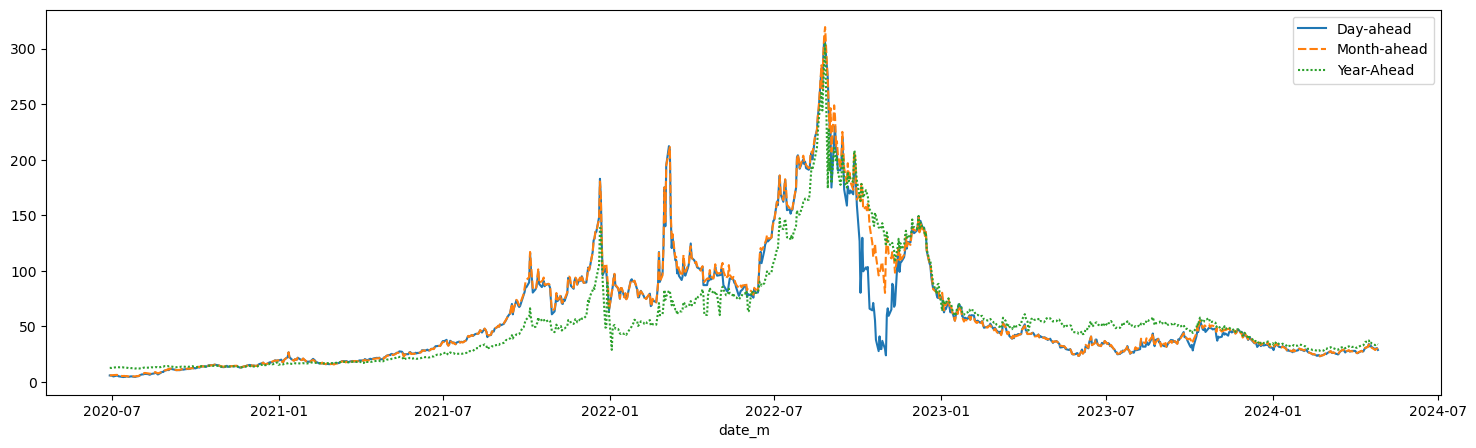

In [2]:
# READ TTF GAS DATA as [TTFData]
dataPrices = pd.read_csv('../../data/bloc_ttf_prices.csv')
dataPrices['date_m'] = pd.to_datetime(dataPrices['date_m'])
dataPrices = dataPrices.set_index('date_m')
fig, ax = plt.subplots(figsize=(18,5))
# sns.set_palette("mako")
sns.lineplot(dataPrices[['Day-ahead','Month-ahead','Year-Ahead']][-1000:], color='Blue'); #3390
#ax2 = plt.twinx()
#sns.lineplot(data=final['€/$'], ax=ax2 , color='grey')
# dataPrices
TTFData = dataPrices['Day-ahead'].values
# # print(d.reshape(-1,1))
# data_train, scaler = Normalize(d)
# # pd
# fig, ax = plt.subplots(figsize=(18,5))
# sns.lineplot(data_train, color='Blue');

## Mask Pattern

In [3]:
def padding_mask(input):
    # Create mask which marks the zero padding values in the input by a 1.0
    mask = math.equal(input, 0)
    print(mask)
    mask = cast(mask, float32)
    print(mask)
    # The shape of the mask should be broadcastable to the shape
    # of the attention weights that it will be masking later on
    return mask[:, newaxis, newaxis, :]

def lookahead_mask(shape):
    # Mask out future entries by marking them with a 1.0
    mask = 1 - linalg.band_part(ones((shape, shape)), -1, 0)
    return mask*(-1e9)

# fig = plt.figure(figsize=(5,2))
# sns.heatmap(lookahead_mask(10))

## Utility fonctions

In [4]:
# Normalize - conver2diff - diff2org
def Normalize(d):
    min_max_scaler = MinMaxScaler((-1,1))
    d = tf.reshape(d, shape=[-1,1])
    scaler = min_max_scaler.fit(d)
    data = scaler.transform(d)
    return data, min_max_scaler

def conver2diff(d, norm=False):
    all = pd.Series(tf.reshape(d,shape=[DATA_SIZE]))
    initDiff = all[0]
    allDiff = all.diff()
    allDiff[0]=0.
    xDiff = tf.convert_to_tensor(allDiff, dtype=tf.float32)
    if (norm):
        xDiff, scalerDiff = Normalize(xDiff)
    else:
        scalerDiff = None
        xDiff = xDiff.numpy()
    return xDiff, scalerDiff, initDiff

def diff2org(d,scalerDiff,xOrigine):
    if (scalerDiff==None):
        all_N = pd.Series(tf.reshape(d,shape=[DATA_SIZE])).to_numpy()
        all_ = all_N.copy()
        all_[0]=xOrigine
        return tf.convert_to_tensor(all_.cumsum())
    else:
        xDiff = scalerDiff.inverse_transform(d)
        all_ = pd.Series(tf.reshape(xDiff,shape=[DATA_SIZE])).to_numpy(dtype=np.float32)
        all_[0]=xOrigine
        return tf.convert_to_tensor(all_.cumsum())

In [5]:
# Implementing the Add & Norm Layer
class AddNormalization(Layer):
    def __init__(self, **kwargs):
        super(AddNormalization, self).__init__(**kwargs)
        self.layer_norm = LayerNormalization()  # Layer normalization layer
 
    def call(self, x, sublayer_x):
        # The sublayer input and output need to be of the same shape to be summed
        x = x + sublayer_x
        x = self.layer_norm(x)
        return x
    
class Normalization(Layer):
    def __init__(self, **kwargs):
        super(Normalization, self).__init__(**kwargs)
        self.Norm = LayerNormalization()
    def call(self, x):
        x = self.Norm(x)
        return x

In [6]:
# Implementing the Feed-Forward Layer
class FeedForward(Layer):
    def __init__(self, d_ff, d_model, **kwargs):
        super(FeedForward, self).__init__(**kwargs)
        self.linear1 = Dense(d_ff)  # First fully connected layer
        self.linear2 = Dense(d_model)  # Second fully connected layer
        self.relu = ReLU()  # ReLU activation layer
 
    def call(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x

In [7]:
# Implementing Dot Product - return Values/Weights
class DotProduct(Layer):
    def __init__(self, **kwargs):
        super(DotProduct, self).__init__(**kwargs)
 
    def call(self, queries, keys, values, mask=None):
        d_k=queries.shape[-1]
        # Scoring the queries against the keys after transposing the latter, and scaling
        scores = matmul(queries, keys, transpose_b=True) / math.sqrt(cast(d_k, float32))
        # Apply mask to the attention scores
        if mask is not None:
            scores += mask
        # Computing the weights by a softmax operation
        weights = softmax(scores)
        out = matmul(weights, values)
        # Computing the attention by a weighted sum of the value vectors
        return out, weights


## Data Embedding

In [45]:
# Simple dat embedding
class DataEmbedding(Layer):
    def __init__(self, d_model, rate, **kwargs):
        super(DataEmbedding,self).__init__(**kwargs)
        self.Linear = Dense(d_model)
        self.Dropout = Dropout(rate)
        self.Norm = LayerNormalization()
    def call(self, x, training=False):
        x = self.Linear(x)
        x = self.Dropout(x, training=training)
        x = self.Norm(x)
        return x
    
# Fixe Positional Embedding - google paper    
class PositionEmbedding(Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super(PositionEmbedding, self).__init__(**kwargs)
        position_embedding_matrix = self.get_position_encoding(seq_len, d_model)                                          
        self.position_embedding_layer = Embedding(
            input_dim=seq_len, output_dim=d_model,
            weights=[position_embedding_matrix],
            trainable=False
        )
    def get_position_encoding(self, seq_len, d, n=10000):
        P = np.zeros((seq_len, d))
        for k in range(seq_len):
            for i in np.arange(int(d/2)):
                denominator = np.power(n, 2*i/d)
                P[k, 2*i] = np.sin(k/denominator)
                P[k, 2*i+1] = np.cos(k/denominator)
        return P
 
    def call(self, inputs):
        position_indices = tf.range(tf.shape(inputs)[1])
        embedded_indices = self.position_embedding_layer(position_indices)
        return embedded_indices
    
# Conv1D embedding
class convEmbedding(Layer):
    def __init__(self, seq_len, d_model, rate, **kwargs):
        super(convEmbedding, self).__init__(**kwargs)
        self.conv1D = Conv1D(d_model,kernel_size=3,padding='same')
        self.dropout = Dropout(rate)
        self.Norm = LayerNormalization()

    def call(self, x, training=False):
        x = self.conv1D(x)
        # x = self.dropout(x, training=training)
        x = self.Norm(x)
        return x

# My data Embedding     
class myEmbedding(Layer):
    def __init__(self,seq_len, d_model, rate, **kwargs):
        super(myEmbedding, self).__init__(**kwargs)
        self.PositionEmb = PositionEmbedding(seq_len, d_model)
        self.DataEmb = DataEmbedding(d_model, rate)
        self.ConvEmb = convEmbedding(seq_len,d_model,rate)
        self.Norm = LayerNormalization()

    def call(self, x, conv=False, training=False):
        # x = tf.cast(x, dtype=tf.float32)
        # x = tf.reshape(x,[x.shape[0],x.shape[1],1])
        x1 = self.PositionEmb(x)
        if (conv):
            x3 = self.ConvEmb(x, training=training)
            # x2 = self.DataEmb(x, training=training)
            out = (x+x1+x3)
        else:
            x2 = self.DataEmb(x, training=training)
            out = (x1+x2)
        out = self.Norm(out)
        return out

## Multi Head Attention

In [9]:
# Implementing the Multi-Head Attention
class MultiHeadAttention(Layer):
    def __init__(self, h, d_model, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.attention = DotProduct()  # Scaled dot product attention
        self.heads = h  # Number of attention heads to use
        self.head_dim = int(d_model / h)
        self.d_model = d_model  # Dimensionality of the model
        self.qkv_layer = Dense(3*d_model)  # Learned projection matrix for the queries
        self.dense = Dense(d_model)  # Learned projection matrix for the multi-head output
  
    def call(self, x, mask=None, value=None):
        batch_size = x.shape[0]
        seq_lenght = x.shape[1]
        input_dim = x.shape[2]
        qkv = self.qkv_layer(x)
        qkv = tf.reshape(qkv,shape=[batch_size , seq_lenght , self.heads , int(3*self.head_dim)])
        qkv = transpose(qkv,perm=(0,2,1,3))
        # print(qkv.shape, batch_size , self.heads, seq_lenght , self.head_dim)
        q = tf.slice(qkv,[0,0,0,0],[batch_size,self.heads,seq_lenght,self.head_dim])
        k = tf.slice(qkv,[0,0,0,self.head_dim],[batch_size,self.heads,seq_lenght,self.head_dim])
        if (value==None):
            v = tf.slice(qkv,[0,0,0,int(2*self.head_dim)],[batch_size,self.heads,seq_lenght,self.head_dim])
        else:
            v = value.slice()
 
        # # Compute the multi-head attention output using the reshaped queries, keys and values
        attention, weights = self.attention(q, k, v, mask)
        # print('attention',attention.shape)
        attention = tf.transpose(attention,perm=(0,2,1,3))
        attention = tf.reshape(attention,shape=[batch_size,seq_lenght,int(self.heads*self.head_dim)])

        # # Apply one final linear projection to the output to generate the multi-head attention
        # # Resulting tensor shape: (batch_size, input_seq_length, d_model)
        # return attention
        return attention,weights

## Encoder

In [10]:
# Implementing Encoder
class EncoderLayer(Layer):
    def __init__(self, h, d_model, rate, d_ff, **kwargs):
        super(EncoderLayer, self).__init__(**kwargs)
        self.h = h
        # self.build(input_shape=[None, sequence_length, d_model])
        self.d_model = d_model
        # self.sequence_length = sequence_length
        self.multihead_attention = MultiHeadAttention(h, d_model)
        self.dropout1 = Dropout(rate)
        self.add_norm1 = AddNormalization()
        self.feed_forward = FeedForward(d_ff, d_model)
        self.dropout2 = Dropout(rate)
        self.add_norm2 = AddNormalization()

    def call(self, x, training=False):
        out,_ = self.multihead_attention(x, None)
        out = self.dropout1(out, training=training)
        out = self.add_norm1(x, out)
        out2 = self.feed_forward(out)
        out2 = self.dropout2(out2, training=training)
        out2 = self.add_norm2(out,out2)
        return out2

class Encoder(Layer):
    def __init__(self, h, d_model, rate, d_ff, N, **kwargs):
        super(Encoder, self).__init__(**kwargs)
        # self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, vocab_size, d_model)
        # self.dropout = Dropout(rate)
        self.encoder_layer = [EncoderLayer(h, d_model, rate, d_ff) for _ in range(N)]

    def call(self, x, training=False):
        for i, layer in enumerate(self.encoder_layer):
            x = layer(x,training)
        return x

In [11]:
#implemente Decoder
class DecoderLayer(Layer):
    def __init__(self, h, d_model, rate, d_ff, **kwargs):
        super(DecoderLayer, self).__init__(**kwargs)
        # self.build(input_shape=[None, sequence_length, d_model])
        self.multihead_attention1 = MultiHeadAttention(h, d_model)
        self.dropout1 = Dropout(rate)
        self.add_norm1 = AddNormalization()
        self.multihead_attention2 = MultiHeadAttention(h, d_model)
        self.dropout2 = Dropout(rate)
        self.add_norm2 = AddNormalization()
        self.feed_forward = FeedForward(d_ff, d_model)
        self.dropout3 = Dropout(rate)
        self.add_norm3 = AddNormalization()
        self.training=False

    def call(self, x, lookahead_mask, encoder_out):
        out,_ = self.multihead_attention1(x, lookahead_mask)
        out = self.dropout1(out, training=self.training)
        out = self.add_norm1(x, out)
        out2 = self.multihead_attention2(out, value=encoder_out)
        out2 = self.dropout2(out2, training=self.training)
        out2 = self.add_norm1(out, out2) 
        out3 = self.feed_forward(out2)
        out3 = self.dropout3(out3, training=self.training)
        out3 = self.add_norm3(out2,out3)
        return out3

class Decoder(Layer):
    def __init__(self, h, d_model, rate, d_ff, N, **kwargs):
        super(Decoder, self).__init__(**kwargs)
        # self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, d_model)
        # self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, vocab_size, d_model)
        self.dropout = Dropout(rate)
        self.decoder_layer = [DecoderLayer(h, d_model, rate, d_ff) for _ in range(N)]

    def call(self, x, encoder_out):
        # Generate the positional encoding
        # pos_encoding_output = self.pos_encoding(output_target)
        # Expected output shape = (number of sentences, sequence_length, d_model)
        training= False
        # Add in a dropout layer
        x = self.dropout(x, training=training)
        for i, layer in enumerate(self.decoder_layer):
            x = layer(x, lookahead_mask, encoder_out)
 
        return x

In [12]:
# Implementing a learning rate scheduler
class LRScheduler(LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000, **kwargs):
        super(LRScheduler, self).__init__(**kwargs)
 
        self.d_model = cast(d_model, float32)
        self.warmup_steps = warmup_steps
 
    def __call__(self, step_num):

        step_num = cast(step_num,float32)
 
        # Linearly increasing the learning rate for the first warmup_steps, and decreasing it thereafter
        arg1 = step_num  ** -0.5
        arg2 = step_num * (self.warmup_steps ** -1.5)
 
        return (self.d_model ** -0.5) * math.minimum(arg1, arg2)

In [13]:
# Defining the loss function
def loss_fcn(y_true, y_pred):
    loss = mean_squared_error(y_true=y_true, y_pred=y_pred)
    # loss = huber_loss(y_true=y_true, y_pred=y_pred)
    # return loss/loss.shape[0]
    return (reduce_sum(loss))

In [14]:
# Defining the accuracy function
def accuracy_fcn(y_true, y_pred):
    accuracy = tf.abs(y_true - y_pred)
    return (1 - reduce_sum(accuracy)/100./accuracy.shape[0])

In [37]:
#My Forecasting 
class myForcast(Model):
    def __init__(self,seq_len, h, d_model,rate, d_ff, N, **kwargs):
        super(myForcast, self).__init__(**kwargs)
        self.MyE = myEmbedding(seq_len,d_model,rate)
        self.Encoder = Encoder(h,d_model,rate,d_ff,N)
        self.linear1 = Dense(d_ff/2)#, activation='sigmoid')
        self.linear2 = Dense(d_ff/8)#, activation='sigmoid')
        self.linear3 = Dense(d_ff/32)#, activation='sigmoid')
        # self.linear4 = Dense(d_ff/128)#, activation='sigmoid')
        self.finish = Dense(1)#, activation='sigmoid')
        self.relu = ReLU()
        self.dropout = Dropout(rate)

    def call(self, x, training=False):
        x = self.MyE(x, conv=False, training=training)
        y = self.Encoder(x,training)
        y = tf.reshape(y, shape=[y.shape[0],y.shape[1]*y.shape[2]])
        y = self.linear1(y)
        y = self.relu(y)
        y = self.dropout(y, training)
        y = self.linear2(y)
        y = self.relu(y)
        y = self.dropout(y, training)
        y = self.linear3(y)
        y = self.relu(y)
        y = self.dropout(y, training)
        # y = self.linear4(y)
        # y = self.dropout(y, training)
        y = self.finish(y)
        # print(y.shape,y.numpy())
        return y

In [16]:
def step(X,y):
    with tf.GradientTape() as tape:
        pred = model(X,training=True)
        loss = loss_fcn(y, pred)
        accuracy = accuracy_fcn(y_true=y, y_pred=pred)
    # grads = tape.gradient(loss,model.trainable_weights)
    grads = tape.gradient(loss,model.trainable_variables)
    optimizer.apply_gradients(zip(grads,model.trainable_variables))
    train_loss(loss)
    train_accuracy(accuracy*100.)

## Prépare DATA

In [46]:
#TEST My Forecast
DATA_SIZE = TTFData.shape[0]
SEQ_LEN = 8
BATCH_SIZE = 32

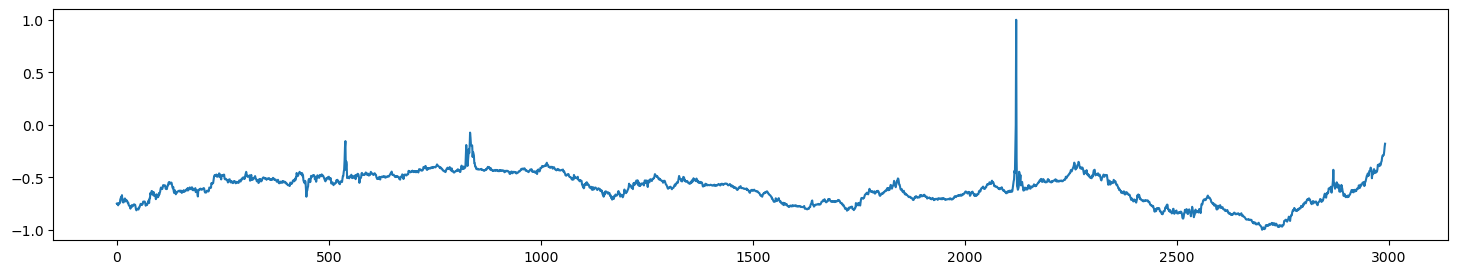

In [48]:
Norm = Normalization()

# Sinusoide de TEST
x = np.sin(np.linspace(0, 100, DATA_SIZE))
x = x + np.random.normal(0, 0.05, DATA_SIZE)
y = np.linspace(0,100,DATA_SIZE)/DATA_SIZE*10
x = x+y
# x,scaler = Normalize(x)
# x,scaler,xOrg = conver2diff(x, False)
# x = Norm(x)

x=TTFData.copy()[:3000]
DATA_SIZE = x.shape[0]
# x,scaler,xOrg = conver2diff(x, False)
x,scaler = Normalize(x)

# Create a dataset
X = np.array([x[ii:ii+SEQ_LEN] for ii in range(0, x.shape[0]-SEQ_LEN)], dtype=np.float32)
Y = np.array([x[ii+SEQ_LEN] for ii in range(0, x.shape[0]-SEQ_LEN)], dtype=np.float32)
X = X.astype('float32')
Y = Y.astype('float32')

X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=369, shuffle=True)#, stratify=Y)

# # Y, fct = Normalize(Y)
# # Y = tf.reshape(Y,shape=[Y.shape[0],1])
# Y = tf.cast(Y, dtype=tf.float32)
# # X = tf.reshape(X, shape=[X.shape[0],SEQ_LEN,1])
# X = tf.cast(X, dtype=tf.float32)

dataset = tf.data.Dataset.from_tensor_slices((X_train,y_train))
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.shuffle(BATCH_SIZE)
datasetVal = tf.data.Dataset.from_tensor_slices((X_val,y_val))
datasetVal = datasetVal.batch(BATCH_SIZE)
datasetVal = datasetVal.shuffle(BATCH_SIZE)
fig = plt.figure(figsize=(18,3))
plt.plot(Y);

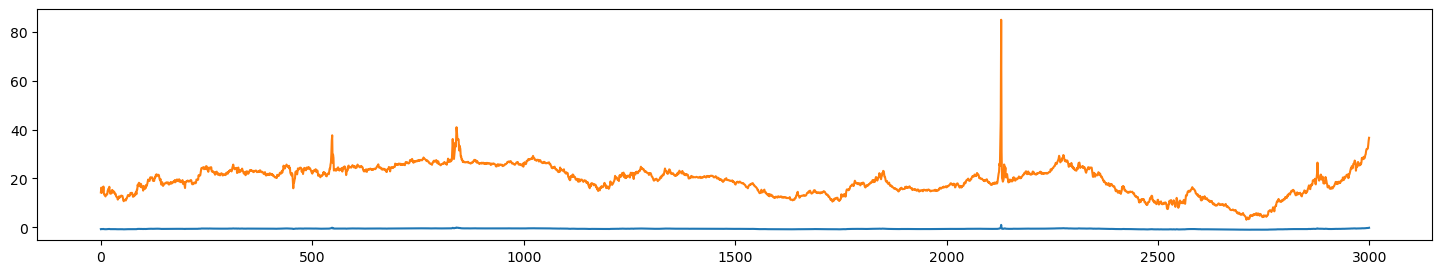

In [49]:
# xD,xScaler,xInit = conver2diff(x)

# xO = diff2org(x,scaler,xOrg)
xO = scaler.inverse_transform(x)
fig = plt.figure(figsize=(18,3))
# plt.plot(xD);
plt.plot(x);
plt.plot(xO);

# TRAINING

In [51]:
####
#TEST My Forecast
h = 8
d_model = 64
d_ff = 512
RATE = 0.1
N = 6
EPOCHS = 12
LR = 2.5e-6

# Include metrics monitoring
train_loss = Mean(name='train_loss')
train_accuracy= Mean(name='train_accuracy')
train_loss_dict = {}
train_accuracy_dict = {}
val_loss = Mean(name='val_loss')
val_accuracy= Mean(name='val_accuracy')
val_loss_dict = {}
val_accuracy_dict = {}

model = myForcast(SEQ_LEN, h, d_model, RATE, d_ff, N)
MyE = myEmbedding(SEQ_LEN, d_model,RATE)
PE = PositionEmbedding(SEQ_LEN,d_model)

# Define the training parameters
beta_1 = 0.9
beta_2 = 0.98
epsilon = 1e-9
# Instantiate an Adam optimizer
optimizer = Adam(LRScheduler(d_model), beta_1, beta_2, epsilon)
# optimizer = Adam(LR, beta_1, beta_2, epsilon)
start_time = time()
for e in range(EPOCHS):
    train_loss.reset_states()
    inter=time()
    for i,(btX,btY) in enumerate(dataset):
        btY = tf.reshape(btY,shape=[btY.shape[0],1])
        btX = tf.reshape(btX, shape=[btX.shape[0],SEQ_LEN,1])
        step(btX,btY)
    train_loss_dict[e] = train_loss.result()
    train_accuracy_dict[e] = train_accuracy.result()

    for i,(btX,btY) in enumerate(datasetVal):
        btY = tf.reshape(btY,shape=[btY.shape[0],1])
        btX = tf.reshape(btX, shape=[btX.shape[0],SEQ_LEN,1])
        pred = model(btX)
        loss = loss_fcn(btY, pred)
        acc = accuracy_fcn(btY, pred)
        val_loss(loss)
        val_accuracy(acc*100.)
    val_loss_dict[e]=val_loss.result()
    val_accuracy_dict[e] = val_accuracy.result()
    print('Epoch:{:>2} -> loss={:>2.2f}/{:>2.2f} -> Accuracy={:>2.2f}%/{:>2.2f}% - [{:.2f}s]'.format(e,train_loss.result(),val_loss.result(),train_accuracy.result(),val_accuracy.result(),(time() - inter)))

# Save the training loss values
with open('./train_loss.pkl', 'wb') as file:
    dump(train_loss_dict, file)
with open('./train_accuracy.pkl', 'wb') as file:
    dump(train_accuracy_dict, file)
with open('./val_loss.pkl', 'wb') as file:
    dump(val_loss_dict, file)
with open('./val_accuracy.pkl', 'wb') as file:
    dump(val_accuracy_dict, file)
print("Total time taken: {:.1f}s".format(time() - start_time))

2024-07-09 06:31:49.113380: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [2393,1]
	 [[{{node Placeholder/_1}}]]
2024-07-09 06:31:49.113539: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [2393,1]
	 [[{{node Placeholder/_1}}]]
2024-07-09 06:31:59.285594: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype float and shape [599

Epoch: 0 -> loss=10.91/1.56 -> Accuracy=99.61%/99.81% - [11.24s]
Epoch: 1 -> loss=0.77/1.65 -> Accuracy=99.74%/99.80% - [10.91s]
Epoch: 2 -> loss=0.77/1.25 -> Accuracy=99.79%/99.83% - [10.44s]
Epoch: 3 -> loss=0.64/0.98 -> Accuracy=99.81%/99.86% - [10.39s]
Epoch: 4 -> loss=0.38/0.98 -> Accuracy=99.83%/99.86% - [10.40s]
Epoch: 5 -> loss=0.24/0.84 -> Accuracy=99.85%/99.87% - [10.50s]
Epoch: 6 -> loss=0.26/0.74 -> Accuracy=99.86%/99.88% - [10.40s]
Epoch: 7 -> loss=0.20/0.67 -> Accuracy=99.87%/99.89% - [10.60s]
Epoch: 8 -> loss=0.19/0.61 -> Accuracy=99.88%/99.90% - [10.47s]
Epoch: 9 -> loss=0.17/0.60 -> Accuracy=99.89%/99.89% - [10.43s]
Epoch:10 -> loss=0.15/0.57 -> Accuracy=99.89%/99.90% - [10.49s]
Epoch:11 -> loss=0.16/0.54 -> Accuracy=99.90%/99.90% - [10.99s]
Total time taken: 127.3s


In [ ]:
# Create a checkpoint object and manager to manage multiple checkpoints
ckpt = train.Checkpoint(model=model, optimizer=optimizer)
ckpt_manager = train.CheckpointManager(ckpt, "./checkpoints", max_to_keep=3)
# Save a checkpoint after every five epochs
save_path = ckpt_manager.save()
# print("Saved checkpoint at epoch %d" % (epoch + 1))
# Save the trained model weights
# model.save_weights("weights/wghts" + str(e + 1) + ".ckpt")
model.save_weights("./weights/wghts_best_TTF" + ".ckpt")

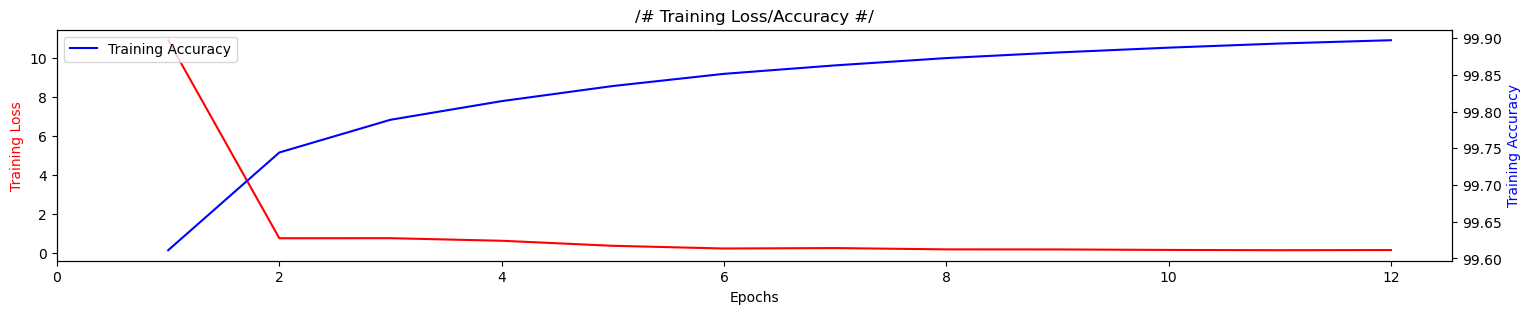

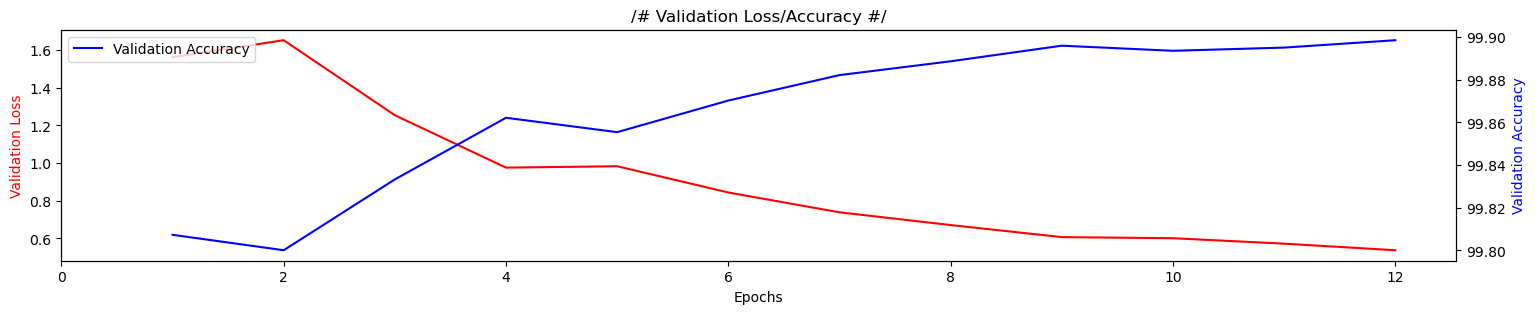

In [52]:
# Visualisation des Courbes d'appretissage
from numpy import arange
from pickle import load
 
# Load the training and validation loss dictionaries
train_loss = load(open('train_loss.pkl', 'rb'))
train_accuracy = load(open('train_accuracy.pkl', 'rb'))
val_loss = load(open('val_loss.pkl', 'rb'))
val_accuracy = load(open('val_accuracy.pkl', 'rb'))
 
# Retrieve each dictionary's values
train_values = train_loss.values()
train_acc_values = train_accuracy.values()
val_values = val_loss.values()
val_acc_values = val_accuracy.values()
 
# Generate a sequence of integers to represent the epoch numbers
g_epochs = range(1, EPOCHS+1)

fig, ax1 = plt.subplots(figsize=(18,3))
ax2 = ax1.twinx()
# Plot and label the training and validation loss values
ax1.plot(g_epochs, train_values, label='Training Loss', color='red')
# ax2.plot(g_epochs, train_values, label='Training Loss', color='blue')
ax2.plot(g_epochs, train_acc_values, label='Training Accuracy', color='blue')
 
# Add in a title and axes labels
plt.title('/# Training Loss/Accuracy #/')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss',color='red')
ax2.set_ylabel('Training Accuracy',color='blue')
# Set the tick locations
plt.xticks(arange(0, EPOCHS+1, 2))
# Display the plot
plt.legend(loc='best');
# plt.show()
#----------------------------
fig, ax1 = plt.subplots(figsize=(18,3))
ax2 = ax1.twinx()
# Plot and label the training and validation loss values
ax1.plot(g_epochs, val_values, label='Validation Loss', color='red')
ax2.plot(g_epochs, val_acc_values, label='Validation Accuracy', color='blue')
# Add in a title and axes labels
plt.title('/# Validation Loss/Accuracy #/')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Validation Loss',color='red')
ax2.set_ylabel('Validation Accuracy',color='blue')
# Set the tick locations
plt.xticks(arange(0, EPOCHS+1, 2))
# Display the plot
plt.legend(loc='best');
# plt.show()

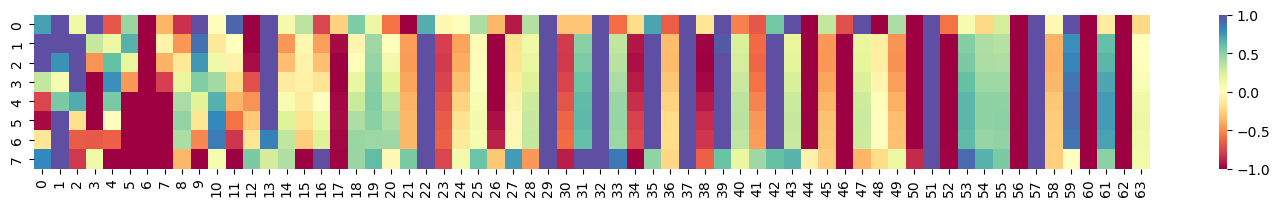

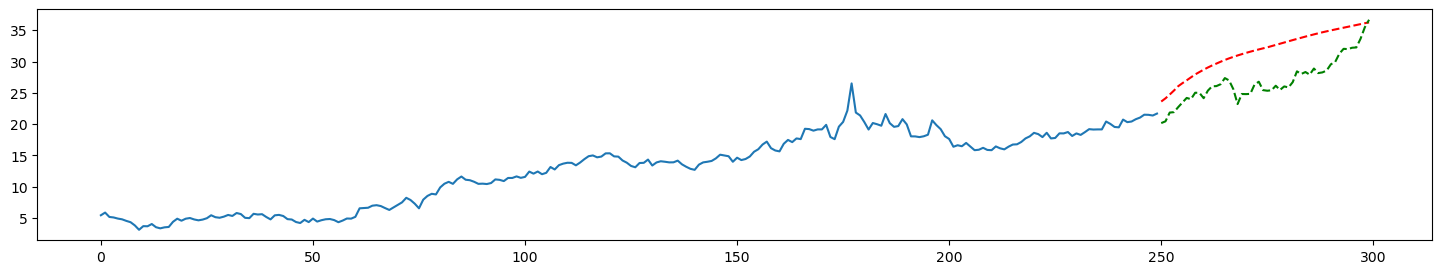

In [54]:
FORCAST = 50
x0 = x[:DATA_SIZE-FORCAST]
x1 = x[:DATA_SIZE]
x0 =tf.reshape(x0,shape=[DATA_SIZE-FORCAST])
x0 = tf.cast(x0, dtype=tf.float32)
for ff in range(FORCAST):
    xx = x0[len(x0)-SEQ_LEN:len(x0)]
    xx = tf.convert_to_tensor(xx, dtype=tf.float32)
    xx = tf.reshape(xx,shape=[1,SEQ_LEN,1])
    myxE = MyE(xx, conv=True, training=False)
    yy = model(xx,training=False)
    yy = tf.reshape(yy,[1])
    x0 = np.concatenate((x0, yy))
fig = plt.figure(figsize=(18,2))
sns.heatmap(myxE[0], vmin=-1, vmax=1, cmap='Spectral');
# ADAPT from transformation initiale des data
x0 = scaler.inverse_transform(tf.reshape(x0,shape=[DATA_SIZE, 1]))
x1 = scaler.inverse_transform(tf.reshape(x1,shape=[DATA_SIZE, 1]))
# x0 = diff2org(tf.reshape(x0,shape=[DATA_SIZE, 1]),scaler,xOrg)
# x1 = diff2org(tf.reshape(x1,shape=[DATA_SIZE, 1]),scaler,xOrg)
# fig, ax = plt.subplots(figsize=(18,5))
# sns.lineplot(d[:], color='Blue');
fig = plt.figure(figsize=(18,3))
LOOP= 300
# plt.plot(range(x0[:DATA_SIZE-FORCAST].shape[0]),x0[:DATA_SIZE-FORCAST], label="Training");
# plt.plot(range(x0[:DATA_SIZE-FORCAST].shape[0], x0.shape[0]),x0[DATA_SIZE-FORCAST:DATA_SIZE], 'r--', label="Predicted");
# plt.plot(range(x1[:DATA_SIZE-FORCAST].shape[0], x1.shape[0]),x1[DATA_SIZE-FORCAST:DATA_SIZE], 'g--', label="Réel");
plt.plot(range(x0[DATA_SIZE-LOOP:DATA_SIZE-FORCAST].shape[0]),x0[DATA_SIZE-LOOP:DATA_SIZE-FORCAST], label="Training");
plt.plot(range(x0[DATA_SIZE-LOOP:DATA_SIZE-FORCAST].shape[0], LOOP),x0[DATA_SIZE-FORCAST:DATA_SIZE], 'r--', label="Predicted");
plt.plot(range(x1[DATA_SIZE-LOOP:DATA_SIZE-FORCAST].shape[0], LOOP),x1[DATA_SIZE-FORCAST:DATA_SIZE], 'g--', label="Réel");

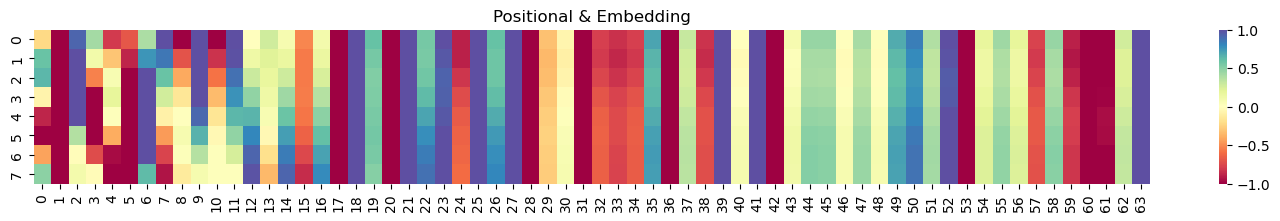

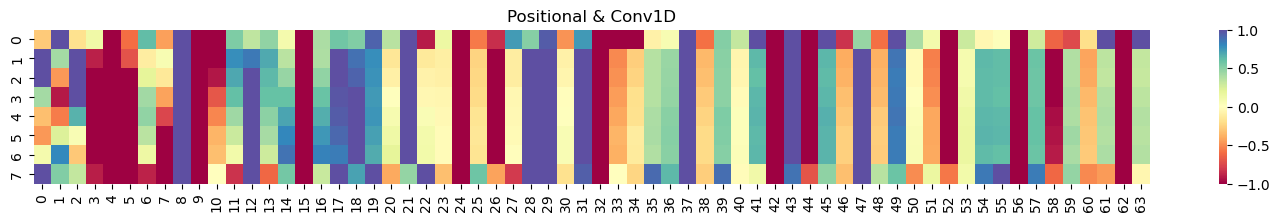

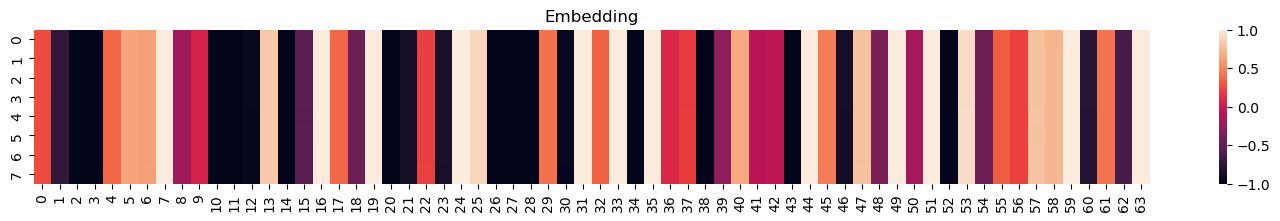

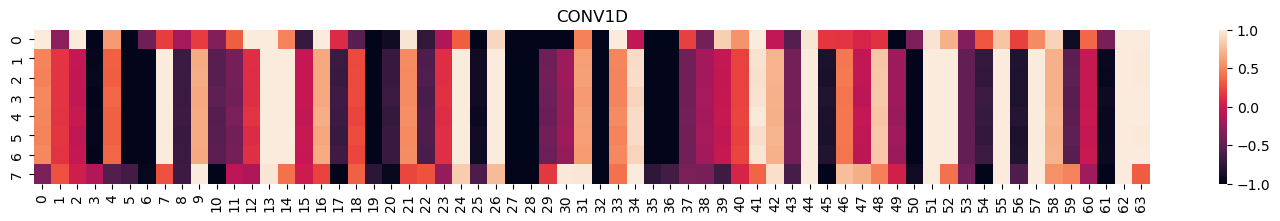

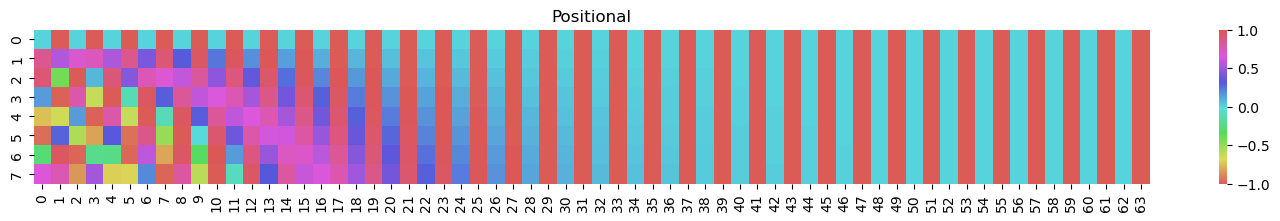

In [50]:
# test convEmbedding
MyE2 = myEmbedding(SEQ_LEN,d_model,RATE)
myConvE = convEmbedding(SEQ_LEN,d_model,RATE)
myE = DataEmbedding(d_model,RATE)
myP = PositionEmbedding(SEQ_LEN,d_model)
mynX = myConvE(btX)
myEX = myE(btX)
myPX = myP(btX)
myX1 = MyE2(btX, conv = False, training=False)
myX2 = MyE2(btX, conv = True, training=False)
# print(mynX.shape, 'vs', myX.shape)
sns.color_palette("hls", 8)
sns.color_palette("mako", as_cmap=True)
fig = plt.figure(figsize=(18,2))
sns.heatmap(myX1[0], vmin=-1, vmax=1, cmap='Spectral').set_title('Positional & Embedding');
fig = plt.figure(figsize=(18,2))
sns.heatmap(myX2[0], vmin=-1, vmax=1, cmap='Spectral').set_title('Positional & Conv1D');
fig = plt.figure(figsize=(18,2))
sns.heatmap(myEX[0], vmin=-1, vmax=1).set_title('Embedding');
fig = plt.figure(figsize=(18,2))
sns.heatmap(mynX[0], vmin=-1, vmax=1).set_title('CONV1D');
fig = plt.figure(figsize=(18,2))
sns.heatmap(myPX, vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional');

In [35]:
from tensorflow import reduce_max, reduce_min
print(reduce_max(myX1).numpy(), reduce_min(myX1).numpy())

NameError: name 'myX1' is not defined

In [ ]:
# TEST DOT PRODUCT
input_seq_length = 10  # Maximum length of the input sequence
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_model = 512  # Dimensionality of the model sub-layers' outputs
batch_size = 32  # Batch size from the training process

# Get a noisy sin wave
DATA_SIZE = 1000
x = np.sin(np.linspace(0, 10, DATA_SIZE))
x = x + np.random.normal(0, 0.05, DATA_SIZE)
# Create a dataset
X = np.array([x[ii:ii+input_seq_length] for ii in range(0, x.shape[0]-input_seq_length)])
Y = np.array([x[ii+input_seq_length] for ii in range(0, x.shape[0]-input_seq_length)])
dataset = tf.data.Dataset.from_tensor_slices((X,Y))
dataset = dataset.batch(batch_size)
dataset = dataset.shuffle(batch_size)
fig = plt.figure(figsize=(10,5))
plt.plot(Y);

#test PositionEMbedding
# PE = PositionEmbedding(input_seq_length, d_model)
DE = DataEmbedding(d_model)
MyE = myEmbedding(input_seq_length, d_model)
EN = Encoder(h, d_model,0.1,1024,4)

for i,(btX,btY) in enumerate(dataset):
    if (i==7):
        print(i,btX.shape)
        outDE = DE(btX)
        fig = plt.figure(figsize=(18,2))
        sns.heatmap(outDE[10], vmin=-0.1, vmax=0.1);
        out = MyE(btX)
        out = EN(out)
        print('Positional Embedding',out.shape)
        fig = plt.figure(figsize=(18,2))
        sns.heatmap(out[10], vmin=-1, vmax=1);

# dataset = tf.data.Dataset.from_tensor_slices((X,Y))
# dataset = dataset.batch(batch_size)
# x, y = zip(*dataset)
# XX = tf.convert_to_tensor(np.concatenate(x))
# YY = tf.convert_to_tensor(np.concatenate(y))
# print('XX, YY',XX.shape, YY.shape)

queries = random.random((batch_size, input_seq_length, d_model))
q = tf.convert_to_tensor(queries, dtype=tf.float32)
# keys = random.random((batch_size, input_seq_length, d_k))
# values = random.random((batch_size, input_seq_length, d_v))

# queries = queries.reshape((batch_size,1,input_seq_length, d_k))
# keys = keys.reshape((batch_size,1,input_seq_length, d_k))
# values = values.reshape((batch_size,1,input_seq_length, d_v))

# q = torch.randn((batch_size,1,input_seq_length, d_model))
# k = torch.randn((batch_size,1,input_seq_length, d_k))
# v = torch.randn((batch_size,1,input_seq_length, d_v))
# print(k.transpose(-1,-2).shape)

# DP = DotProduct()
MH = MultiHeadAttention(h,d_model)
AN = AddNormalization()
mask = lookahead_mask(int(input_seq_length))
print("mask",mask.shape)
print('entrée',q.shape)
# attention, weights = DP(queries,keys,values,mask)
attention,weights = MH(q,mask)
print(attention.shape,weights.shape)
fig = plt.figure(figsize=(5,3))
sns.heatmap(weights[10][7], vmin=-1, vmax=1);

output = AN(q,attention)
print("sortie",output.shape,tf.reduce_mean(output[10]))
fig = plt.figure(figsize=(18,2))
sns.heatmap(output[0], vmin=-5, vmax=5);
# print(weights[1][1])
# sns.heatmap(mask);


# Tattention, Tweights = scaled_dot_product(q,k,v)
# print(Tattention.shape)

EN = Encoder(h, d_model,0.1,1024,4)
out = EN(q)
print('Encoder output',q.shape)
fig = plt.figure(figsize=(18,2))
sns.heatmap(out[12], vmin=-5, vmax=5);
